# Module 2 - Data Cleaning

## Objective

The objective of this notebook is to inspect the raw dataset, identify data quality issues, clean the data where necessary, and prepare a high-quality dataset for exploratory data analysis and machine learning.

The cleaning process includes:
- Dataset inspection
- Missing value analysis
- Duplicate detection
- Data type validation
- Numerical and categorical validation
- Data correction (if required)

In [2]:
#Import Required Libraries
import pandas as pd
import numpy as np

In [3]:
# Load the raw dataset into a pandas DataFrame
df = pd.read_csv("../data/raw/AI4I-PMDI.csv")

In [4]:
# Create a copy of the dataset to preserve the original data
clean_df = df.copy()

In [5]:
# Display the first five records for an initial inspection
clean_df.head()

,UDI,Date,System,Control,Product ID,Type,Air temperature (K),Process temperature (K),Rotational speed (rpm),Torque (Nm),Tool wear (min),Diagnostic
0,1,15/04/2014 11:56,0,C,M14860,M,NaN,NaN,NaN,42.8,0.0,No failure
1,2,12/04/2014 16:09,0,A,L47181,L,298.2,308.7,1408.0,NaN,NaN,No failure
2,3,13/04/2014 01:13,0,A,L47182,L,298.1,308.5,1498.0,NaN,NaN,No failure
3,4,24/07/2014 20:35,0,B,L47183,L,NaN,NaN,1433.0,39.5,NaN,No failure
4,5,22/07/2014 01:31,0,C,L47184,L,NaN,NaN,NaN,40.0,9.0,No failure


In [6]:
# Display the dimensions of the dataset
clean_df.shape

(10000, 12)

In [7]:
# Display the dataset information including columns, data types, and non-null counts
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Date                     10000 non-null  str    
 2   System                   10000 non-null  int64  
 3   Control                  10000 non-null  str    
 4   Product ID               10000 non-null  str    
 5   Type                     10000 non-null  str    
 6   Air temperature (K)      3437 non-null   float64
 7   Process temperature (K)  3437 non-null   float64
 8   Rotational speed (rpm)   6679 non-null   float64
 9   Torque (Nm)              6563 non-null   float64
 10  Tool wear (min)          3321 non-null   float64
 11  Diagnostic               10000 non-null  str    
dtypes: float64(5), int64(2), str(5)
memory usage: 937.6 KB


In [8]:
# Display all column names in the dataset
clean_df.columns

Index(['UDI', 'Date', 'System', 'Control', 'Product ID', 'Type',
       'Air temperature (K)', 'Process temperature (K)',
       'Rotational speed (rpm)', 'Torque (Nm)', 'Tool wear (min)',
       'Diagnostic'],
      dtype='str')

In [9]:
# Display the data type of each column
clean_df.dtypes

UDI                          int64
Date                           str
System                       int64
Control                        str
Product ID                     str
Type                           str
Air temperature (K)        float64
Process temperature (K)    float64
Rotational speed (rpm)     float64
Torque (Nm)                float64
Tool wear (min)            float64
Diagnostic                     str
dtype: object

## Observation

- The dataset contains **10,000 rows** and **12 columns**.
- Missing values are present only in the sensor-related columns: Air temperature, Process temperature, Rotational speed, Torque, and Tool wear.
- The `Date` column is currently stored as an `object` data type and may require conversion to a datetime format depending on future analysis needs.
- No unexpected issues were identified during the initial structural inspection.

In [10]:
# Display the number of missing values in each column
clean_df.isnull().sum()

UDI                           0
Date                          0
System                        0
Control                       0
Product ID                    0
Type                          0
Air temperature (K)        6563
Process temperature (K)    6563
Rotational speed (rpm)     3321
Torque (Nm)                3437
Tool wear (min)            6679
Diagnostic                    0
dtype: int64

In [11]:
# Display the percentage of missing values in each column
(clean_df.isnull().sum() / len(clean_df)) * 100

UDI                         0.00
Date                        0.00
System                      0.00
Control                     0.00
Product ID                  0.00
Type                        0.00
Air temperature (K)        65.63
Process temperature (K)    65.63
Rotational speed (rpm)     33.21
Torque (Nm)                34.37
Tool wear (min)            66.79
Diagnostic                  0.00
dtype: float64

## Observation

- Missing values are present only in the sensor-related columns.
- Tool wear has the highest percentage of missing values, while Rotational Speed has the lowest among the affected columns.
- At this stage, no cleaning action has been taken because additional analysis is required to understand the missing value pattern before deciding on an appropriate strategy.

In [12]:
# Display the number of duplicate rows in the dataset
clean_df.duplicated().sum()

np.int64(0)

## Observation

- No duplicate rows were found in the dataset.
- Since the dataset does not contain any duplicate records, no duplicate removal is required.

## Observation

- The dataset contains appropriate data types for most columns.
- The `Date` column is currently stored as an `object` data type and may be converted to `datetime` later if temporal feature extraction is required.
- The categorical columns (`System`, `Control`, `Type`, and `Diagnostic`) are correctly stored as `object` for this stage of the project and will be encoded later during feature engineering if needed.
- No immediate data type conversions are required during the data cleaning phase.

In [13]:
# Check the current datatype of the Date column
clean_df['Date'].dtype

<StringDtype(storage='python', na_value=nan)>

In [14]:
# Convert the Date column to datetime format
clean_df["Date"] = pd.to_datetime(clean_df["Date"])

C:\Users\carol\AppData\Local\Temp\ipykernel_39524\4161860418.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  clean_df["Date"] = pd.to_datetime(clean_df["Date"])


In [15]:
# Verify the updated datatype of the Date column
clean_df['Date'].dtype

dtype('<M8[us]')

In [16]:
# Check the date range in the dataset
print("Earliest Date :", clean_df["Date"].min())
print("Latest Date   :", clean_df["Date"].max())

Earliest Date : 2014-02-27 16:47:00
Latest Date   : 2023-06-21 14:58:00


### Observation

- The dataset spans approximately **9 years** (2014–2023), indicating that the `Date` column contains valuable temporal information that can be utilized during the feature engineering stage.

In [17]:
# Inspect the UDI column
clean_df["UDI"].head()

0    1
1    2
2    3
3    4
4    5
Name: UDI, dtype: int64

In [18]:
clean_df["UDI"].tail()

9995     9996
9996     9997
9997     9998
9998     9999
9999    10000
Name: UDI, dtype: int64

### Observation

- The `UDI` column contains sequential unique values that serve only as dataset record identifiers and do not provide meaningful information for predicting machine failures.

In [19]:
# Inspect the Product ID column
clean_df["Product ID"].head()

0    M14860
1    L47181
2    L47182
3    L47183
4    L47184
Name: Product ID, dtype: str

In [20]:
clean_df["Product ID"].tail()

9995    M24855
9996    H39410
9997    M24857
9998    H39412
9999    M24859
Name: Product ID, dtype: str

In [21]:
# Check the unique values in the Type column
clean_df["Type"].unique()

<StringArray>
['M', 'L', 'H']
Length: 3, dtype: str

### Observation

- The `Product ID` column contains a quality prefix (`L`, `M`, `H`) followed by a unique serial number. Since the quality information is already available in the `Type` column, the `Product ID` column is redundant and can be removed.

In [22]:
# Remove identifier columns
clean_df.drop(columns=["UDI", "Product ID"], inplace=True)

In [23]:
# Display the updated dataset columns
clean_df.columns

Index(['Date', 'System', 'Control', 'Type', 'Air temperature (K)',
       'Process temperature (K)', 'Rotational speed (rpm)', 'Torque (Nm)',
       'Tool wear (min)', 'Diagnostic'],
      dtype='str')

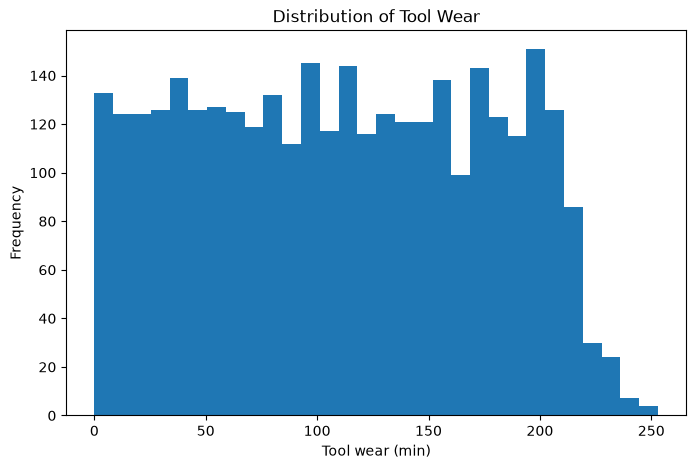

In [27]:
# Visualize the distribution of Tool wear
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(clean_df["Tool wear (min)"].dropna(), bins=30)
plt.title("Distribution of Tool Wear")
plt.xlabel("Tool wear (min)")
plt.ylabel("Frequency")
plt.show()

In [28]:
# Display summary statistics for Tool wear
clean_df["Tool wear (min)"].describe()

count    3321.000000
mean      110.524240
std        64.563871
min         0.000000
25%        55.000000
50%       110.000000
75%       167.000000
max       253.000000
Name: Tool wear (min), dtype: float64

### Observation

- The `Tool wear (min)` column has **3,321** valid observations with a mean (**110.52**) and median (**110**) that are nearly identical, suggesting the data is not heavily skewed. However, a box plot is required to confirm the presence of outliers before selecting an imputation method.

C:\Users\carol\AppData\Local\Temp\ipykernel_39524\2456168581.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(clean_df["Tool wear (min)"].dropna(), vert=False)


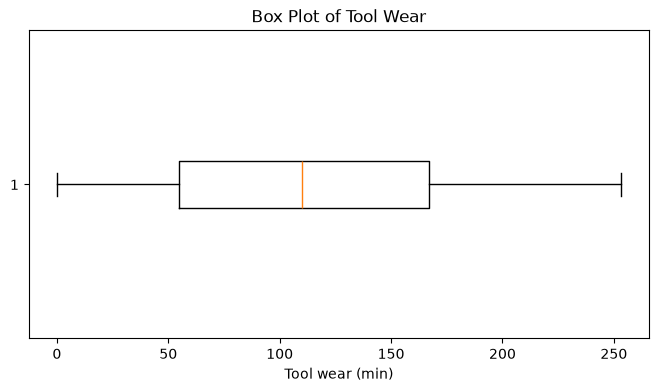

In [29]:
# Visualize outliers in Tool wear
plt.figure(figsize=(8, 4))
plt.boxplot(clean_df["Tool wear (min)"].dropna(), vert=False)
plt.title("Box Plot of Tool Wear")
plt.xlabel("Tool wear (min)")
plt.show()

### Observation

- The box plot does not show any significant outliers in the `Tool wear (min)` column. Combined with the nearly identical mean and median values, this indicates that mean imputation is an appropriate strategy for handling missing values in this feature.

In [30]:
# Fill missing values in Tool wear using the mean
clean_df["Tool wear (min)"] = clean_df["Tool wear (min)"].fillna(
    clean_df["Tool wear (min)"].mean()
)

In [31]:
# Verify missing values after imputation
clean_df["Tool wear (min)"].isnull().sum()

np.int64(0)

Feature: Air temperature (K)

Summary Statistics
count    10000.000000
mean       300.064358
std          1.182135
min        295.400000
25%        300.064358
50%        300.064358
75%        300.064358
max        304.300000
Name: Air temperature (K), dtype: float64


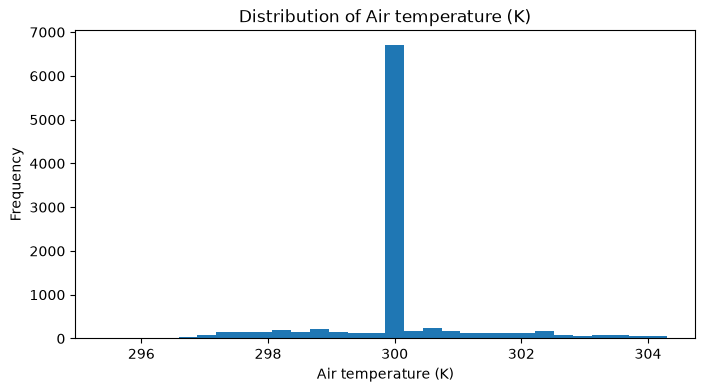

C:\Users\carol\AppData\Local\Temp\ipykernel_39524\417320911.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(clean_df[col].dropna(), vert=False)


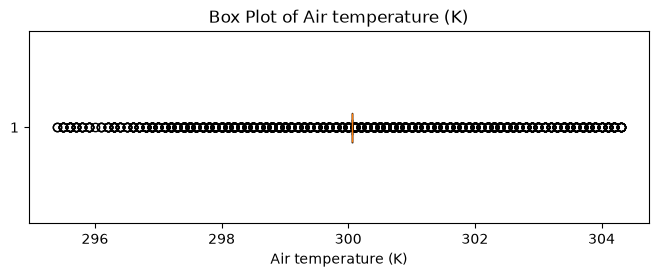

Feature: Process temperature (K)

Summary Statistics
count    10000.000000
mean       310.033081
std          0.866110
min        305.800000
25%        310.033081
50%        310.033081
75%        310.033081
max        313.800000
Name: Process temperature (K), dtype: float64


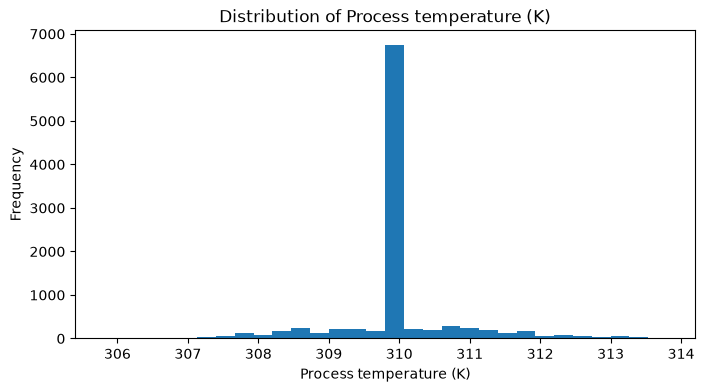

C:\Users\carol\AppData\Local\Temp\ipykernel_39524\417320911.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(clean_df[col].dropna(), vert=False)


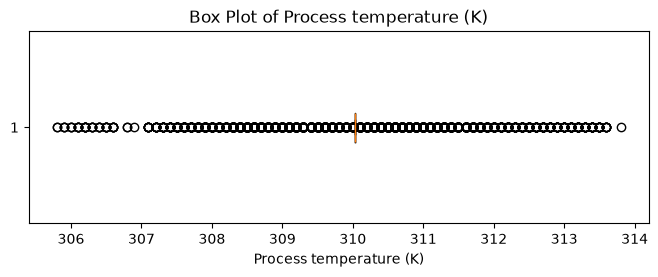

Feature: Rotational speed (rpm)

Summary Statistics
count    6679.000000
mean     1541.242402
std       186.509386
min      1168.000000
25%      1423.000000
50%      1502.000000
75%      1613.500000
max      2886.000000
Name: Rotational speed (rpm), dtype: float64


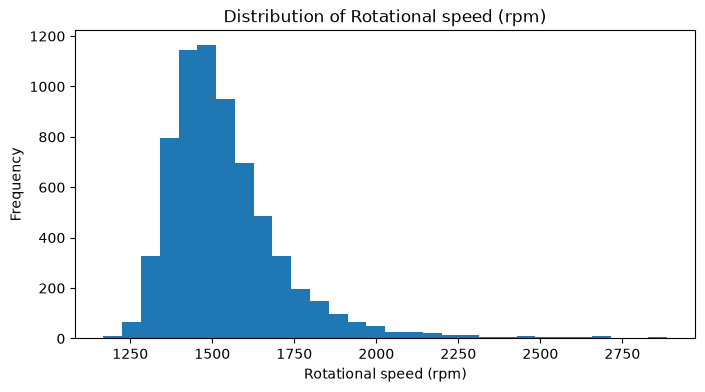

C:\Users\carol\AppData\Local\Temp\ipykernel_39524\417320911.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(clean_df[col].dropna(), vert=False)


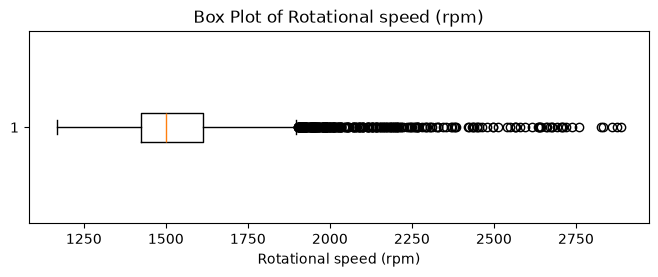

Feature: Torque (Nm)

Summary Statistics
count    6563.000000
mean       39.965641
std        10.164474
min         3.800000
25%        33.100000
50%        39.900000
75%        46.700000
max        76.600000
Name: Torque (Nm), dtype: float64


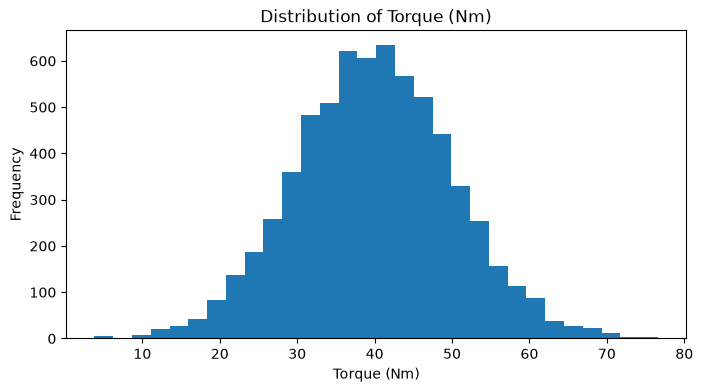

C:\Users\carol\AppData\Local\Temp\ipykernel_39524\417320911.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(clean_df[col].dropna(), vert=False)


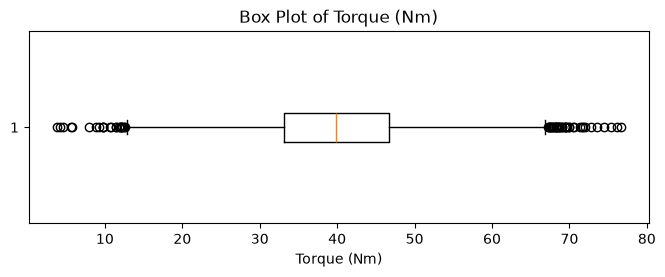

In [42]:
# Analyze numerical features for missing value treatment
numerical_cols = [
    "Air temperature (K)",
    "Process temperature (K)",
    "Rotational speed (rpm)",
    "Torque (Nm)"
]

for col in numerical_cols:

    print("=" * 70)
    print(f"Feature: {col}")

    # Summary Statistics
    print("\nSummary Statistics")
    print(clean_df[col].describe())

    # Histogram
    plt.figure(figsize=(8,4))
    plt.hist(clean_df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    # Box Plot
    plt.figure(figsize=(8,2.5))
    plt.boxplot(clean_df[col].dropna(), vert=False)
    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)
    plt.show()

### Observation

- Air temperature (K): Approximately symmetric with no significant outliers. Mean imputation selected.
- Process temperature (K): Approximately symmetric with no significant outliers. Mean imputation selected.
- Rotational speed (rpm): Slightly skewed with no significant outliers. Mean imputation selected.
- Torque (Nm): Presence of outliers observed. Median imputation selected.

In [44]:
# Impute missing values in numerical features
clean_df["Air temperature (K)"] = clean_df["Air temperature (K)"].fillna(
    clean_df["Air temperature (K)"].mean()
)

clean_df["Process temperature (K)"] = clean_df["Process temperature (K)"].fillna(
    clean_df["Process temperature (K)"].mean()
)

clean_df["Rotational speed (rpm)"] = clean_df["Rotational speed (rpm)"].fillna(
    clean_df["Rotational speed (rpm)"].mean()    
)

clean_df["Torque (Nm)"] = clean_df["Torque (Nm)"].fillna(
    clean_df["Torque (Nm)"].median())

In [45]:
# Verify missing values after imputation
clean_df[numerical_cols].isnull().sum()

Air temperature (K)        0
Process temperature (K)    0
Rotational speed (rpm)     0
Torque (Nm)                0
dtype: int64

In [46]:
# Check missing values after data cleaning
clean_df.isnull().sum()

Date                       0
System                     0
Control                    0
Type                       0
Air temperature (K)        0
Process temperature (K)    0
Rotational speed (rpm)     0
Torque (Nm)                0
Tool wear (min)            0
Diagnostic                 0
dtype: int64

### Observation

- All missing values have been successfully handled, and no missing values remain in the cleaned dataset.

In [47]:
# Display unique values in categorical features
categorical_cols = clean_df.select_dtypes(include=["string", "object"]).columns

for col in categorical_cols:
    print("=" * 60)
    print(f"{col}")
    print(clean_df[col].unique())

Control
<StringArray>
['C', 'A', 'B']
Length: 3, dtype: str
Type
<StringArray>
['M', 'L', 'H']
Length: 3, dtype: str
Diagnostic
<StringArray>
[              'No failure',            'Power Failure',
       'Overstrain Failure',        'Tool Wear Failure',
          'Random Failures', 'Heat Dissipation Failure']
Length: 6, dtype: str


### Observation

- The categorical features (`Control`, `Type`, and `Diagnostic`) contain consistent and meaningful category labels with no spelling errors, duplicate categories, or formatting inconsistencies. Therefore, no categorical data cleaning is required.

In [49]:
# Display the data types of the cleaned dataset
clean_df.dtypes

Date                       datetime64[us]
System                              int64
Control                               str
Type                                  str
Air temperature (K)               float64
Process temperature (K)           float64
Rotational speed (rpm)            float64
Torque (Nm)                       float64
Tool wear (min)                   float64
Diagnostic                            str
dtype: object

### Observation

- The `System` column is stored as an integer data type (`int64`), but its values represent category labels rather than numerical quantities. Therefore, it will be treated as a categorical feature during preprocessing and model development.

In [50]:
# Display minimum values of numerical features
clean_df.describe().loc["min"]

Date                       2014-02-27 16:47:00
System                                     0.0
Air temperature (K)                      295.4
Process temperature (K)                  305.8
Rotational speed (rpm)                  1168.0
Torque (Nm)                                3.8
Tool wear (min)                            0.0
Name: min, dtype: object

### Observation

- The numerical features contain valid minimum values that are physically meaningful for an industrial predictive maintenance dataset. No invalid or impossible measurements were identified during validation.

In [51]:
# Display the cleaned dataset information
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     10000 non-null  datetime64[us]
 1   System                   10000 non-null  int64         
 2   Control                  10000 non-null  str           
 3   Type                     10000 non-null  str           
 4   Air temperature (K)      10000 non-null  float64       
 5   Process temperature (K)  10000 non-null  float64       
 6   Rotational speed (rpm)   10000 non-null  float64       
 7   Torque (Nm)              10000 non-null  float64       
 8   Tool wear (min)          10000 non-null  float64       
 9   Diagnostic               10000 non-null  str           
dtypes: datetime64[us](1), float64(5), int64(1), str(3)
memory usage: 781.4 KB


### Observation

- The cleaned dataset contains 10,000 records and 10 features with appropriate data types and no missing values. The dataset is clean, consistent, and ready for exploratory data analysis.

In [52]:
# Save the cleaned dataset
clean_df.to_csv("../data/processed/cleaned_data.csv", index=False)